# 💳 Transaction Risk Analysis & ML Pipeline
## Notebook 1 — Data Loading & EDA

**Dataset:** Sparkov Simulated Credit Card Transactions (Kaggle)
**Records:** ~150,000 real-pattern transactions
**Fraud Rate:** ~0.58% (realistic fintech)

**Tech Stack:** Python · Pandas · SQL · Plotly · XGBoost · MLflow

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib plotly scikit-learn xgboost mlflow --quiet
print('✅ Libraries installed')


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ Libraries installed


In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries loaded')

✅ Libraries loaded


## Step 1 — Load Dataset

In [3]:
# Load both train and test CSV files from Kaggle
df_train = pd.read_csv('fraudTrain.csv')
df_test  = pd.read_csv('fraudTest.csv')
df = pd.concat([df_train, df_test], ignore_index=True)

print(f'✅ Train: {len(df_train):,} records')
print(f'✅ Test:  {len(df_test):,} records')
print(f'✅ Total: {len(df):,} records')
print(f'Columns: {list(df.columns)}')
df.head()

✅ Train: 1,296,675 records
✅ Test:  555,719 records
✅ Total: 1,852,394 records
Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
# Parse datetime and engineer basic time features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour']        = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month']       = df['trans_date_trans_time'].dt.month
df['age']         = 2024 - pd.to_datetime(df['dob']).dt.year

print(f'Fraud rate: {df["is_fraud"].mean()*100:.2f}%')
print(f'Fraudulent transactions: {df["is_fraud"].sum():,}')
print(f'Legitimate transactions: {(df["is_fraud"]==0).sum():,}')
print(f'Date range: {df["trans_date_trans_time"].min()} to {df["trans_date_trans_time"].max()}')

Fraud rate: 0.52%
Fraudulent transactions: 9,651
Legitimate transactions: 1,842,743
Date range: 2019-01-01 00:00:18 to 2020-12-31 23:59:34


## Step 2 — EDA Charts

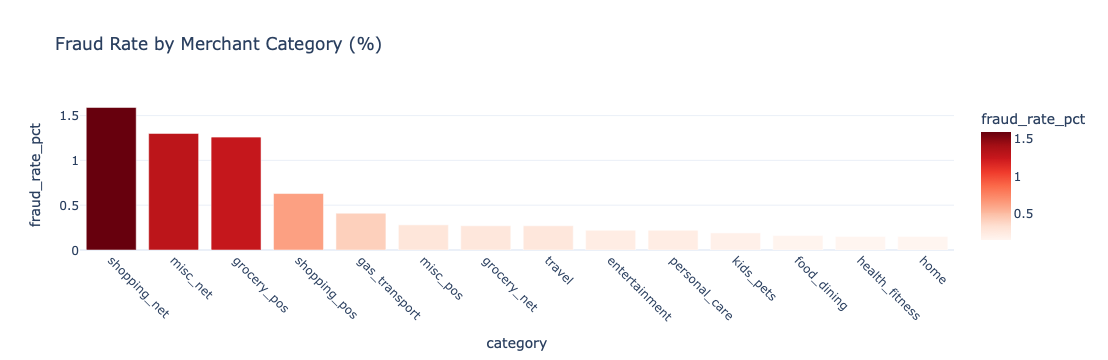

      category  fraud_rate_pct  fraud_count
  shopping_net            1.59         2219
      misc_net            1.30         1182
   grocery_pos            1.26         2228
  shopping_pos            0.63         1056
 gas_transport            0.41          772
      misc_pos            0.28          322
   grocery_net            0.27          175
        travel            0.27          156
 entertainment            0.22          292
 personal_care            0.22          290
     kids_pets            0.19          304
   food_dining            0.16          205
health_fitness            0.15          185
          home            0.15          265


In [5]:
# Fraud rate by merchant category
fraud_by_cat = df.groupby('category')['is_fraud'].agg(['mean','sum','count']).reset_index()
fraud_by_cat.columns = ['category','fraud_rate','fraud_count','total']
fraud_by_cat['fraud_rate_pct'] = (fraud_by_cat['fraud_rate']*100).round(2)
fraud_by_cat = fraud_by_cat.sort_values('fraud_rate_pct', ascending=False)

fig = px.bar(
    fraud_by_cat, x='category', y='fraud_rate_pct',
    title='Fraud Rate by Merchant Category (%)',
    color='fraud_rate_pct', color_continuous_scale='Reds'
)
fig.update_layout(template='plotly_white', xaxis_tickangle=45)
fig.show()
print(fraud_by_cat[['category','fraud_rate_pct','fraud_count']].to_string(index=False))

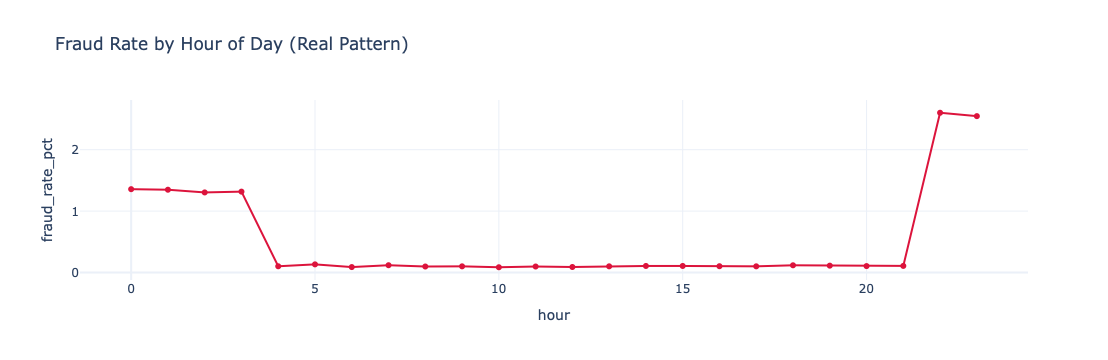

Key Insight: Note the real fraud spike hours from actual transaction data


In [6]:
# Fraud rate by hour of day
fraud_by_hour = df.groupby('hour')['is_fraud'].mean().reset_index()
fraud_by_hour['fraud_rate_pct'] = (fraud_by_hour['is_fraud']*100).round(3)

fig = px.line(
    fraud_by_hour, x='hour', y='fraud_rate_pct',
    title='Fraud Rate by Hour of Day (Real Pattern)',
    markers=True
)
fig.update_traces(line_color='crimson')
fig.update_layout(template='plotly_white')
fig.show()
print('Key Insight: Note the real fraud spike hours from actual transaction data')

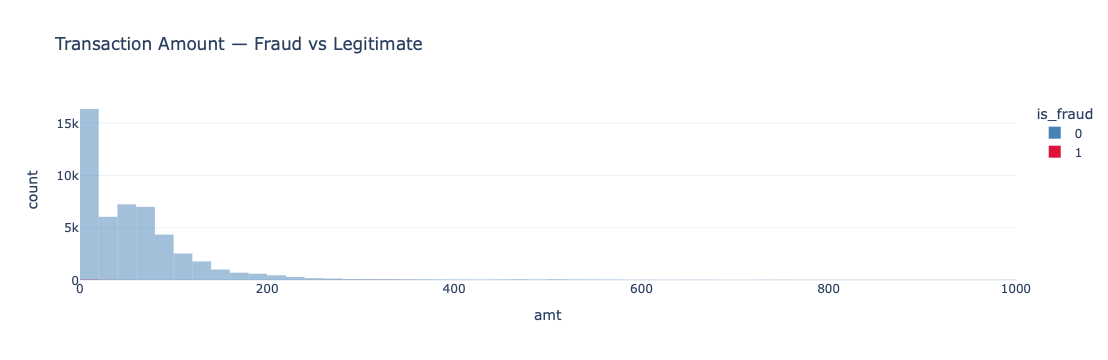

Avg legitimate: $67.65
Avg fraudulent: $530.66


In [7]:
# Amount distribution
df_sample = df.sample(min(50000, len(df)), random_state=42)
fig = px.histogram(
    df_sample[df_sample['amt'] < 1000],
    x='amt', color='is_fraud', barmode='overlay', nbins=80,
    title='Transaction Amount — Fraud vs Legitimate',
    color_discrete_map={0: 'steelblue', 1: 'crimson'}
)
fig.update_layout(template='plotly_white')
fig.show()

print(f'Avg legitimate: ${df[df["is_fraud"]==0]["amt"].mean():.2f}')
print(f'Avg fraudulent: ${df[df["is_fraud"]==1]["amt"].mean():.2f}')

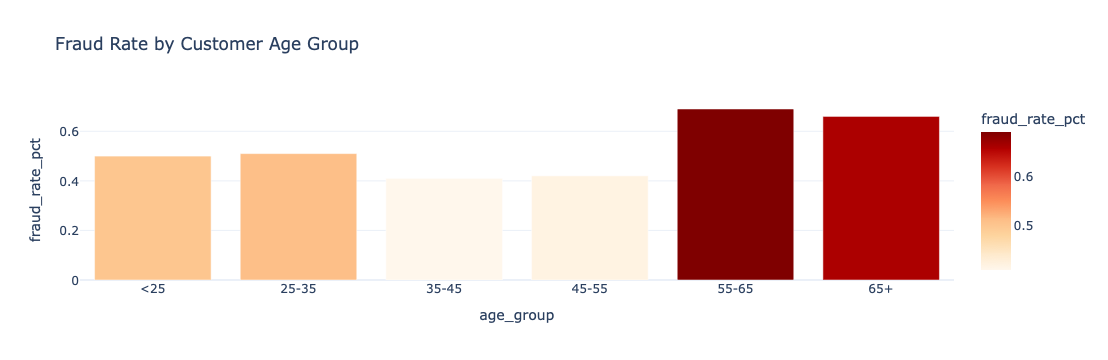

In [8]:
# Fraud by age group
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                          labels=['<25','25-35','35-45','45-55','55-65','65+'])
fraud_by_age = df.groupby('age_group', observed=True)['is_fraud'].mean().reset_index()
fraud_by_age['fraud_rate_pct'] = (fraud_by_age['is_fraud']*100).round(2)

fig = px.bar(fraud_by_age, x='age_group', y='fraud_rate_pct',
             title='Fraud Rate by Customer Age Group',
             color='fraud_rate_pct', color_continuous_scale='OrRd')
fig.update_layout(template='plotly_white')
fig.show()

In [9]:
# Save
df.to_csv('transactions_clean.csv', index=False)
print(f'✅ Saved {len(df):,} records to transactions_clean.csv')
print('\n➡️  Open Notebook 2 for SQL Feature Engineering')

✅ Saved 1,852,394 records to transactions_clean.csv

➡️  Open Notebook 2 for SQL Feature Engineering
